## Implementing the RandomWiring Class
The RandomWiring class is responsible for defining the connection architecture between neurons. It initializes random adjacency matrices for neuron connections and sensory inputs. Those are used as an arbitrary sparsity matrix later in LIFNeuralLayer

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F

In [2]:
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, 32)   # Input to hidden layer 1
        self.fc2 = nn.Linear(32, 28)  # Hidden layer 1 to 2
        self.fc3 = nn.Linear(28, 20)  # Hidden layer 2 to 3
        self.fc4 = nn.Linear(20, output_dim)   # Hidden layer 3 to output

    def forward(self, x):
        x = F.relu(self.fc1(x))  # Activation after fc1
        x = F.relu(self.fc2(x))  # Activation after fc2
        x = F.relu(self.fc3(x))  # Activation after fc3
        x = self.fc4(x)          # Final output (no activation, e.g., for regression or logits)
        return x

## Generating Spiral Data
We will generate a dataset of spiral trajectories to train and evaluate our model. The generate_spiral_data function creates synthetic data points forming a spiral pattern.

In [3]:
# Generate spiral data
def generate_spiral_data(num_points, num_turns, noise = 2):
    theta = np.linspace(0, num_turns * 2 * np.pi, num_points)
    z = np.linspace(0, 1, num_points)
    r = z
    x = r * np.sin(theta) + noise * np.random.randn(*theta.shape) / num_points
    y = r * np.cos(theta) + noise * np.random.randn(*theta.shape) / num_points
    return np.stack([x, y], axis=1)

## Training the Model
Next, we set the hyperparameters and prepare the data for training. We define a training loop to train the model using the generated spiral data.

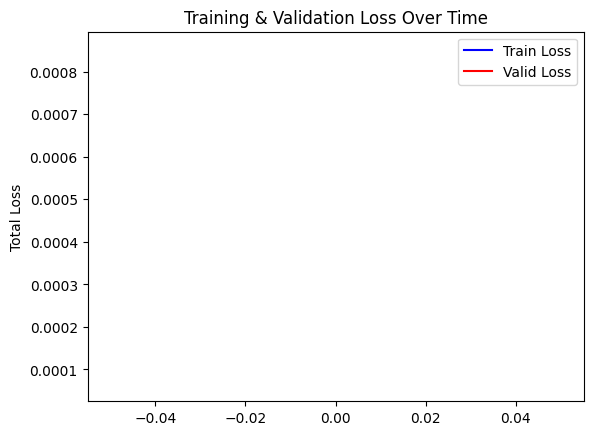

Epoch 100/1000, Total Train Loss: 0.0008547062, , Total Valid Loss: 0.0000647174


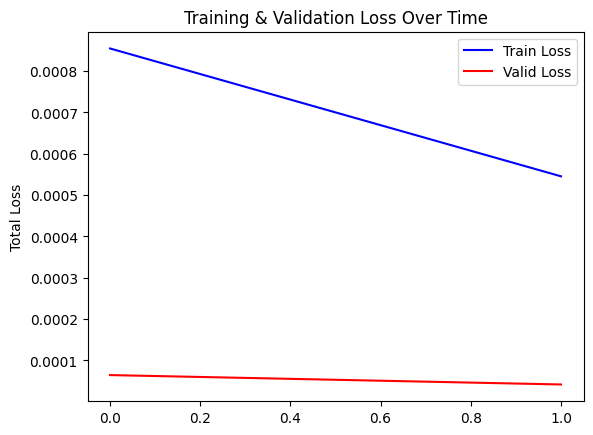

Epoch 200/1000, Total Train Loss: 0.0005455144, , Total Valid Loss: 0.0000420023


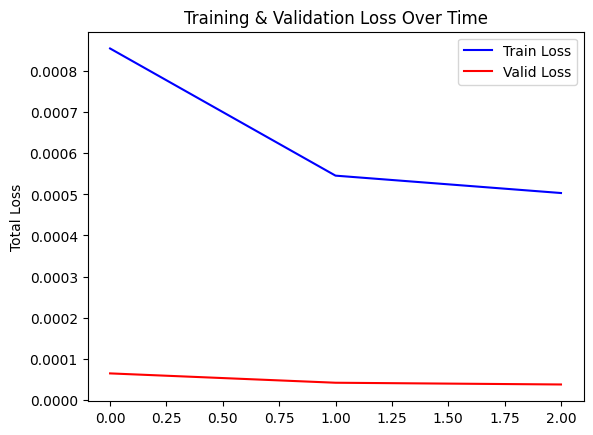

Epoch 300/1000, Total Train Loss: 0.0005032670, , Total Valid Loss: 0.0000377729


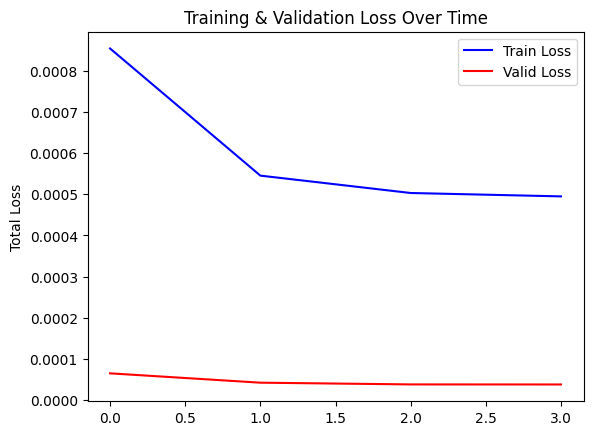

Epoch 400/1000, Total Train Loss: 0.0004950298, , Total Valid Loss: 0.0000376332


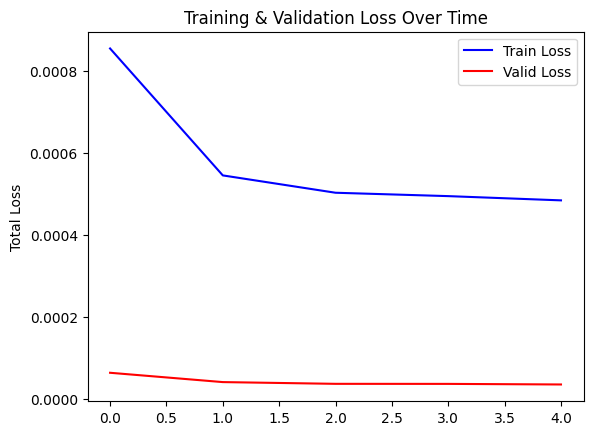

Epoch 500/1000, Total Train Loss: 0.0004847063, , Total Valid Loss: 0.0000362010


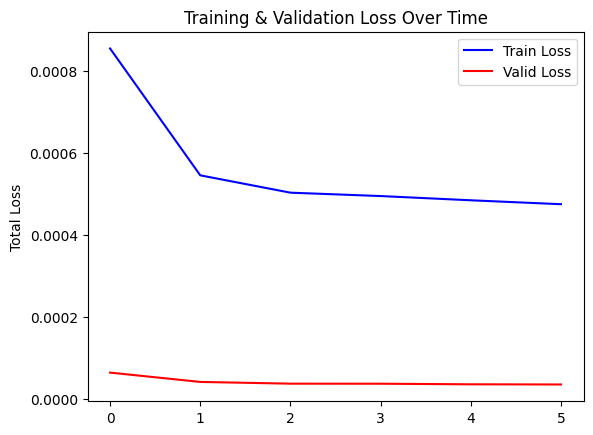

Epoch 600/1000, Total Train Loss: 0.0004751443, , Total Valid Loss: 0.0000357879


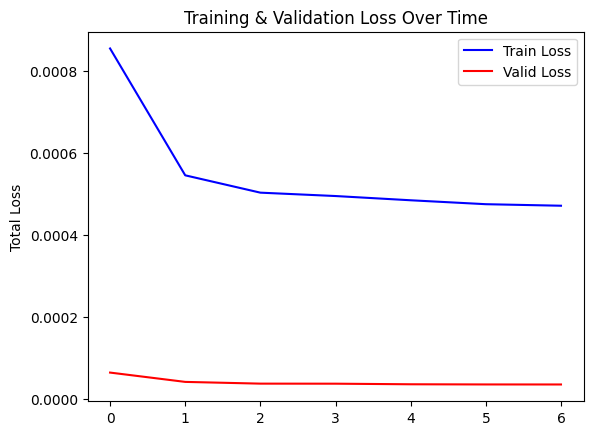

Epoch 700/1000, Total Train Loss: 0.0004714145, , Total Valid Loss: 0.0000357119


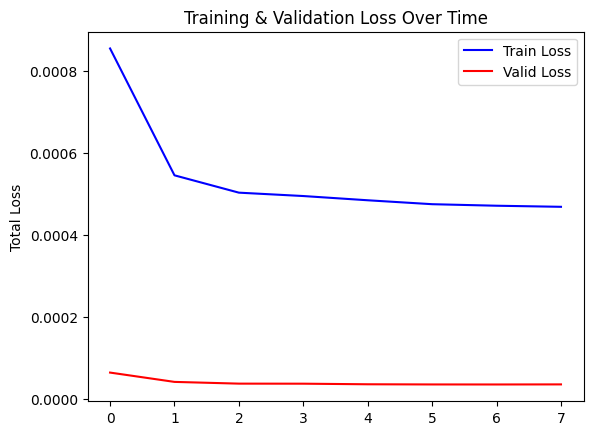

Epoch 800/1000, Total Train Loss: 0.0004687736, , Total Valid Loss: 0.0000359190


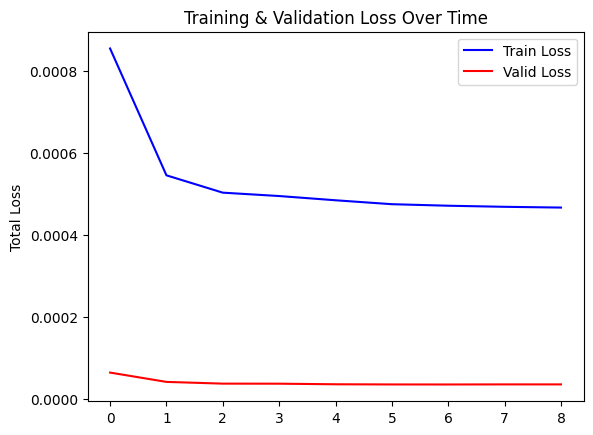

Epoch 900/1000, Total Train Loss: 0.0004669271, , Total Valid Loss: 0.0000359010


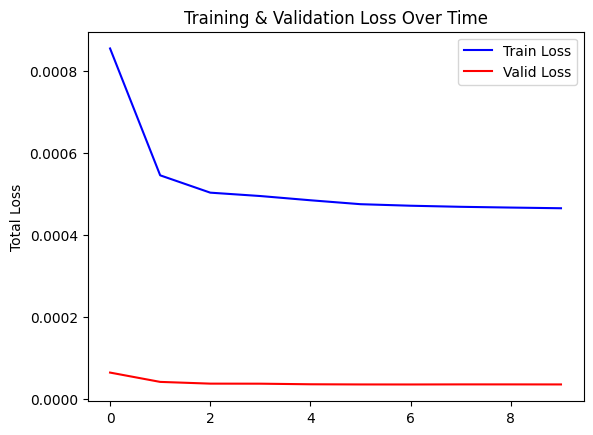

Epoch 1000/1000, Total Train Loss: 0.0004652749, , Total Valid Loss: 0.0000358069


In [4]:
# Hyperparameters
input_dim = 2 # Number of input dimensions
output_dim = 2 # Number of output dimensions
num_points = 500 # Number of spiral points in dataset
num_turns = 3 # Number of spiral turns
learning_rate = 0.0005
num_epochs = 1000
seq_len = 3 # Maximum length of the sample sequence
batch_size = 32

# Generate data
data = generate_spiral_data(num_points, num_turns)
all_inputs = data[:-1, :]
all_targets = data[1:, :]

# Prepare input and target sequences
trajectory_count = max(1, len(all_inputs) - seq_len)
train_inputs = [torch.FloatTensor(all_inputs[i:i + seq_len]) for i in range(trajectory_count)]
train_targets = [torch.FloatTensor(all_targets[i:i + seq_len]) for i in range(trajectory_count)]

# Shuffle and split the data for training
random_indices = np.arange(len(train_inputs))
np.random.shuffle(random_indices)
train_split_index = int(len(random_indices) * 0.8)
random_train_indices = random_indices[:train_split_index]
random_valid_indices = random_indices[train_split_index:]

# Create train and validation sets
train_inputs_split = [train_inputs[i] for i in random_train_indices]
train_labels_split = [train_targets[i] for i in random_train_indices]

valid_inputs_split = [train_inputs[i] for i in random_valid_indices]
valid_labels_split = [train_targets[i] for i in random_valid_indices]

# print(train_inputs_split)
# print(valid_inputs_split)


# Function to create batches
def create_batches(data_list, batch_size):
    return [data_list[i:i + batch_size] for i in range(0, len(data_list), batch_size)]

# Create input and target batches
train_input_batches = create_batches(train_inputs_split, batch_size)
train_target_batches = create_batches(train_labels_split, batch_size)

# Initialize model
model = SimpleMLP(input_dim, output_dim)

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

total_train_losses = []
total_valid_losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()    
    total_train_loss = 0

    # Iterate over batches
    for x, y_target in zip(train_input_batches, train_target_batches):
        optimizer.zero_grad()
        x = torch.stack(x)  # Stack batch of sequences
        y_target = torch.stack(y_target)  # Stack batch of targets
        outputs = model(x)  # Forward pass through the model
        loss = criterion(outputs, y_target)  # Compute loss

        # Accumulate total loss and perform backward pass and optimization step
        total_train_loss += loss.item()
        loss.backward()
        optimizer.step()
    

    # Print loss every 100 epochs and plot predictions
    if (epoch + 1) % 100 == 0:
        total_val_loss = 0
        # Prediction and plotting
        model.eval()
        with torch.no_grad():
            predictions = model(torch.stack(valid_inputs_split))
            total_valid_loss = criterion(predictions, torch.stack(valid_labels_split))  # Compute loss
        
            # Compute average loss for this epoch
            total_train_losses.append(total_train_loss)
            total_valid_losses.append(total_valid_loss)


        # Plot the average loss curve
        plt.plot(total_train_losses, color='b', label="Train Loss")  # Plot every plot_epoch_no epoch's loss
        plt.plot(total_valid_losses, color='r', label="Valid Loss")
        plt.ylabel('Total Loss')
        plt.title('Training & Validation Loss Over Time')
        plt.legend()
        plt.show()
        print(f"Epoch {epoch+1}/{num_epochs}, Total Train Loss: {total_train_loss:.10f}, , Total Valid Loss: {total_valid_loss:.10f}")


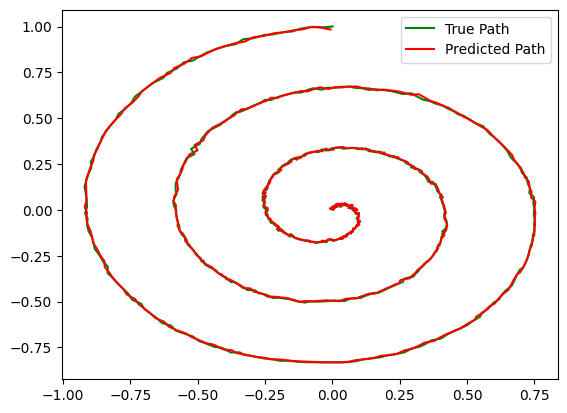

In [5]:
model.eval()
with torch.no_grad():
    predictions = model(torch.FloatTensor(all_inputs).unsqueeze(0))
    np_predictions = predictions.squeeze(0).numpy()
    val_loss = criterion(predictions, torch.FloatTensor(all_targets).unsqueeze(0))  # Compute loss
    
plt.plot(all_targets[:, 0], all_targets[:, 1], 'g-', label='True Path')
plt.plot(np_predictions[:, 0], np_predictions[:, 1], 'r-', label='Predicted Path')
plt.legend()
plt.show()

# Conclusions
In this tutorial we have implemented a classic LTC LNN as described in the original whitepaper. 

There are further imporvements available to the LNN architecture. 

Such as: 
* [Closed-form Continuous-Time Network models](https://arxiv.org/abs/2106.13898)
* [LTC-SE](https://arxiv.org/abs/2304.08691)
* [Liquid-S4](https://arxiv.org/abs/2209.12951)